In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('returns.csv')

## 01 - Data Inspection

In [73]:
df.head(5)

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   return_id        39939 non-null  object 
 1   order_id         39939 non-null  int64  
 2   product_id       39939 non-null  int64  
 3   return_date      39939 non-null  object 
 4   return_reason    39939 non-null  object 
 5   return_quantity  39939 non-null  int64  
 6   refund_amount    39939 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 2.1+ MB


In [75]:
df.shape

(39939, 7)

## 02 - Data Types

In [76]:
for i in df.columns:
  display(df[i].apply(type).value_counts())

,count
return_id,
<class 'str'>,39939


,count
order_id,
<class 'int'>,39939


,count
product_id,
<class 'int'>,39939


,count
return_date,
<class 'str'>,39939


,count
return_reason,
<class 'str'>,39939


,count
return_quantity,
<class 'int'>,39939


,count
refund_amount,
<class 'float'>,39939


## 03 - Missing Values

In [77]:
df.isnull().sum()

,0
return_id,0
order_id,0
product_id,0
return_date,0
return_reason,0
return_quantity,0
refund_amount,0


In [78]:
df.isna().sum()

,0
return_id,0
order_id,0
product_id,0
return_date,0
return_reason,0
return_quantity,0
refund_amount,0


In [79]:
df.head(5)

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76


In [80]:
placeholders = ['N/A', 'NA', 'n/a', 'null', 'None', 'none', '-', '--', '?',
                 'unknown', 'Unknown', 'nan', '#N/A', 'missing']

mask_placeholder = df['return_id'].astype(str).str.strip().isin(placeholders)
print("Số dòng dùng placeholder giả:", mask_placeholder.sum())
print(df.loc[mask_placeholder, 'return_id'].value_counts())

Số dòng dùng placeholder giả: 0
Series([], Name: count, dtype: int64)


In [81]:
placeholders = ['N/A', 'NA', 'n/a', 'null', 'None', 'none', '-', '--', '?',
                 'unknown', 'Unknown', 'nan', '#N/A', 'missing']

mask_placeholder = df['return_reason'].astype(str).str.strip().isin(placeholders)
print("Số dòng dùng placeholder giả:", mask_placeholder.sum())
print(df.loc[mask_placeholder, 'return_reason'].value_counts())

Số dòng dùng placeholder giả: 0
Series([], Name: count, dtype: int64)


In [82]:
# Kiem tra dong co tat ca gia tri deu thieu
df[df.isnull().all(axis=1)]


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount


In [83]:
# Kiem tra dong co tat ca gia tri deu thieu
df[df.isnull().all(axis=1)]


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount


## 04 - Duplicates & Invalid Data

In [84]:
df[df.duplicated()]


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount


In [85]:
df['return_id'].duplicated().sum()

np.int64(0)

In [86]:
# Loại bỏ cột khóa chính ra khỏi việc so sánh
cols_to_check = [c for c in df.columns if c != 'promo_id']

duplicates = df[df.duplicated(subset=cols_to_check, keep=False)]
print("Số dòng trùng nội dung (khác id):", len(duplicates))
duplicates.sort_values(cols_to_check)

Số dòng trùng nội dung (khác id): 0


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount


In [87]:
df[(df['refund_amount'] <= 0) | (df['return_quantity'] <= 0)].count()


,0
return_id,0
order_id,0
product_id,0
return_date,0
return_reason,0
return_quantity,0
refund_amount,0


In [88]:
df['return_reason'].value_counts()

,count
return_reason,
wrong_size,13967
defective,8020
not_as_described,7035
changed_mind,6931
late_delivery,3986


## 05 - Outliers

In [89]:
df.describe()
# return_quatity la so luong don tra hang, co cac gia tri giua max, mean, Q3, Q1 khong dang ke, khong dang lo ngai
# refund_amount co gia tri giua min-Q1, Q3-max, chênh lenh bat thuong can xem xet


,order_id,product_id,return_quantity,refund_amount
count,39939.000000,39939.000000,39939.000000,39939.000000
mean,409061.984176,1244.232730,2.743834,12784.458964
std,240063.904576,691.747822,1.828260,14092.150154
min,2.000000,3.000000,1.000000,458.810000
25%,202651.000000,702.000000,1.000000,3573.395000
50%,404254.000000,992.000000,2.000000,7888.880000
75%,615620.000000,2048.000000,4.000000,16881.990000
max,833351.000000,2412.000000,8.000000,160937.940000


In [90]:
Q1 = df['refund_amount'].quantile(0.25)
Q3 = df['refund_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['refund_amount'] < lower_bound) | (df['refund_amount'] > upper_bound)]
print("Số dòng outlier refund_amount:", len(outliers))

Số dòng outlier refund_amount: 2778


{'whiskers': [<matplotlib.lines.Line2D at 0x7fe9ac101e50>,
 'caps': [<matplotlib.lines.Line2D at 0x7fe9ac101bd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fe9ac101f90>],
 'medians': [<matplotlib.lines.Line2D at 0x7fe9ac1020d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fe9ac102710>],
 'means': []}

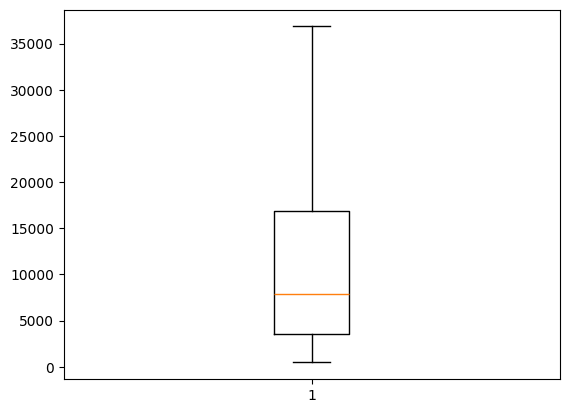

In [95]:
plt.boxplot(df['refund_amount'])

In [92]:
# vì trường dữ liệu outlier = 2778, khá nhỏ so với 39,939 ta có thể

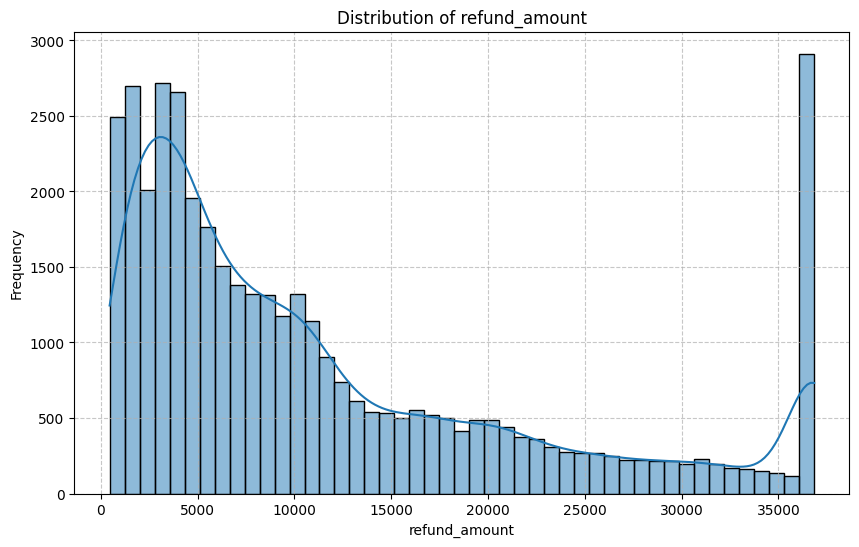

In [96]:
def plot_distribution_skewness(df, column_name):
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column_name], kde=True)
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
plot_distribution_skewness(df, 'refund_amount')
# kha lech khuyen dung tranforms, nhưng thầy dặn là upload lại về file đã làm sạch nên hạn chế
# thay doi dư lieu nen dung Capping / Winsorizing (giới hạn về ngưỡng)

In [94]:
df['refund_amount'] = df['refund_amount'].clip(lower_bound, upper_bound)

In [98]:
df.to_csv("return_cleaned.csv", index=False)